In [5]:
from sklearn.svm import SVC
from tensorflow.keras.datasets import mnist

In [69]:
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
X_train = X_train_full[:5000]
y_train = y_train_full[:5000]

X_train = X_train / 255.

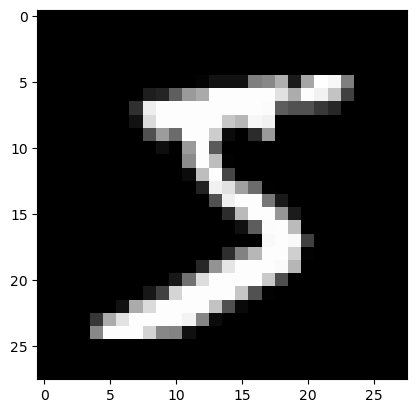

In [71]:
import matplotlib.pyplot as plt 

plt.imshow(X_train[0], cmap='grey')

In [73]:
flatten = X_train[0].ravel()

In [75]:
flatten

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [77]:
flatten_list = []

for digit in X_train:
    flatten_list.append(digit.ravel())

In [79]:
svc = SVC()

In [81]:
y_train_full

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [83]:
import numpy as np

flatten_list = np.array(flatten_list)

In [85]:
svc.fit(flatten_list, y_train)

SVC()

In [86]:
svc.score(flatten_list, y_train)

0.9872

In [88]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [163]:
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras import Sequential, Model

In [165]:
model = Sequential()
model.add(Input(shape=(28, 28)))
model.add(Flatten())
model.add(Dense(300, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [167]:
from tensorflow.keras.optimizers import Adam

In [169]:
optimizer = Adam()

In [171]:
model.compile(optimizer = optimizer, metrics=['accuracy'], loss='sparse_categorical_crossentropy')

In [173]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [177]:
history = model.fit(X_train, y_train, epochs=20)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9342 - loss: 0.2288
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.1573
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9771 - loss: 0.0960
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9825 - loss: 0.0634
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9922 - loss: 0.0369
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9952 - loss: 0.0262
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0221
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9995 - loss: 0.0076
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9979 - loss: 0.0106
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9990 - loss: 0.0061
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0029
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [193]:
new_model = Model(inputs=[model.inputs], outputs=[model.layers[-2].output])

In [209]:
pred = new_model.predict(X_train)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step


In [213]:
new_svc = SVC()
new_svc.fit(pred, y_train)

SVC()

In [215]:
new_svc.score(pred, y_train)

1.0

In [219]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [221]:
pca.fit(pred)

PCA(n_components=2)

In [223]:
dimensional_reduced_vectors = pca.transform(pred)

In [225]:
dimensional_reduced_vectors

array([[ -5.963093 , -11.843444 ],
       [  2.2599592, -11.3958025],
       [  1.1374047,  10.961229 ],
       ...,
       [  1.4921231, -13.433595 ],
       [  0.7391836,   1.3822254],
       [  5.439772 ,  -2.4096658]], dtype=float32)

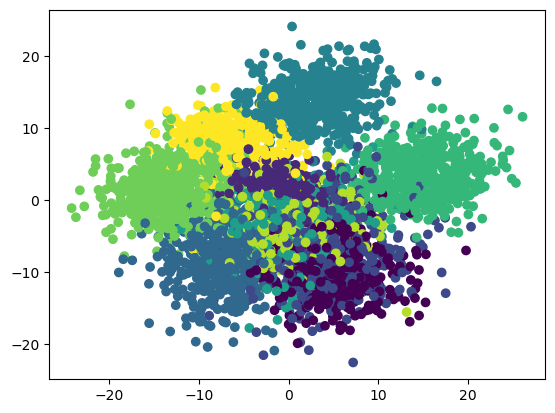

In [227]:
plt.scatter(dimensional_reduced_vectors[:, 0], dimensional_reduced_vectors[:, 1], c=y_train)

In [229]:
from sklearn.manifold import TSNE

In [231]:
tsne = TSNE(n_components=2)
tsne.fit(pred)

TSNE()

In [235]:
tsne_reduced = tsne.fit_transform(pred)

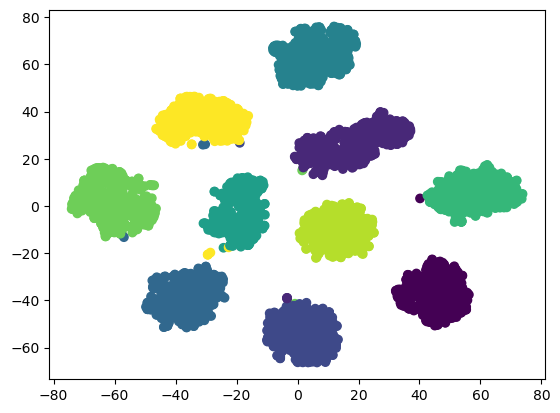

In [237]:
plt.scatter(tsne_reduced[:, 0], tsne_reduced[:, 1], c=y_train)